# GuidelineForge — Inter-Annotator Agreement & QA Analysis
**Support-ticket intent + sentiment annotation program, 600 tickets · 3 annotators · 2 rounds**

This notebook recomputes every statistic in the project from the raw label
files. Metrics are implemented from scratch in `src/agreement.py` and
cross-validated against scikit-learn / NLTK / the canonical Fleiss (1971)
worked example — because in a quality-engineering discipline, *the measuring
instruments get calibrated first*.

| | |
|---|---|
| Corpus | 600 support tickets (520 real Bitext rows + 80 documented ambiguity injections) |
| Tasks | intent (8 classes) + sentiment (ordinal: negative < neutral < positive) |
| Design | 180-ticket blind triple-overlap for IAA · 72-item gold set · 48-item calibration set |
| Rounds | R1 under guidelines v1.0 → disagreement analysis → v2.0 → R2 → tiered QA |

In [1]:
# locate the repo root no matter where Jupyter was launched from
import os, pathlib, sys, json
_cands = [pathlib.Path.cwd(), pathlib.Path.cwd().parent,
          pathlib.Path.cwd().parent.parent]
ROOT = next(p for p in _cands
            if (p / "guidelines").exists() and (p / "src").exists())
os.chdir(ROOT / "notebooks")          # notebook paths are relative to here
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
from agreement import (cohen_kappa, fleiss_kappa, krippendorff_alpha,
                        bootstrap_ci, per_class_kappa, confusion_pairs,
                        observed_agreement, run_self_tests)

corpus = pd.read_csv("../data/raw/support_tickets.csv")
gold   = pd.read_csv("../data/gold_set.csv")
r1     = pd.read_csv("../data/annotations/annotations_round1.csv")
r2     = pd.read_csv("../data/annotations/annotations_round2.csv")
M      = json.load(open("../results/metrics.json"))
print(f"corpus={len(corpus)}  overlap={corpus.in_overlap.sum()}  "
      f"gold={corpus.is_gold.sum()}  calibration={corpus.is_calibration.sum()}")
print(f"R1 labels={len(r1)} (540 overlap + 420 production)  R2 labels={len(r2)}")

corpus=600  overlap=180  gold=72  calibration=48
R1 labels=960 (540 overlap + 420 production)  R2 labels=960


## 0 · Instrument calibration — the metrics correct *before* they're trusted
Self-tests: perfect-agreement sanity, Cohen vs scikit-learn (bit-exact),
Fleiss vs NLTK **and** the published 0.210 reference value, Krippendorff α
vs NLTK (16 digits).

In [2]:
run_self_tests()

  cohen_perfect                True
  fleiss_perfect               True
  alpha_perfect                True
  fleiss_wikipedia_0.210       True
  _fleiss_wiki_value           0.2099
  cohen_matches_sklearn        True
  _fleiss_mine_vs_nltk         (np.float64(0.5362), 0.5364)
  fleiss_matches_nltk          True
  _alpha_mine_vs_nltk          (0.5369, 0.5369)
  alpha_matches_nltk           True
  _alpha_ordinal_mine_vs_nltk  (0.5649, 0.5649)
  alpha_ordinal_matches_nltk_interval True


{'cohen_perfect': np.True_,
 'fleiss_perfect': np.True_,
 'alpha_perfect': True,
 'fleiss_wikipedia_0.210': np.True_,
 '_fleiss_wiki_value': np.float64(0.2099),
 'cohen_matches_sklearn': np.True_,
 '_fleiss_mine_vs_nltk': (np.float64(0.5362), 0.5364),
 'fleiss_matches_nltk': np.True_,
 '_alpha_mine_vs_nltk': (0.5369, 0.5369),
 'alpha_matches_nltk': True,
 '_alpha_ordinal_mine_vs_nltk': (0.5649, 0.5649),
 'alpha_ordinal_matches_nltk_interval': True}

## 1 · Corpus composition & the taxonomy
The corpus mixes organic tickets with five *planted* ambiguity families —
the patterns that break real annotation programs. Ambiguity is deliberate:
agreement statistics are meaningless on trivially easy data.

In [3]:
summ = (corpus.groupby("ambiguity_type")
        .agg(n=("ticket_id", "count"),
             in_overlap=("in_overlap", "sum"),
             gold=("is_gold", "sum")))
print(summ.to_string())
print("\nIntent classes:", sorted(corpus.design_intent.unique()))

                    n  in_overlap  gold
ambiguity_type                         
mixed_intent       18          16     6
none              520         108    48
polite_complaint   14          13     4
sarcasm            24          20     6
short_fragment      8           7     2
tone_trap          16          16     6

Intent classes: ['account_access', 'billing_payments', 'cancellation', 'feedback_complaints', 'order_changes', 'other_contact', 'refund_request', 'shipping_delivery']


## 2 · Round 1 — how much did the annotators disagree?
Backoff ladder: raw unanimity → pairwise Cohen's κ → multi-rater Fleiss' κ →
Krippendorff's α (ordinal for sentiment, since 'negative-vs-positive' is a
*larger* error than 'negative-vs-neutral' and α's distance metric prices
that in).

In [4]:
ov_ids = corpus[corpus.in_overlap].ticket_id.tolist()
def seq(ann, task):
    piv = ann[ann.ticket_id.isin(ov_ids)].pivot(index="ticket_id",
                                                columns="annotator",
                                                values=task)
    return [piv[a].tolist() for a in ["A1", "A2", "A3"]]

i1, s1 = seq(r1, "intent"), seq(r1, "sentiment")
i2, s2 = seq(r2, "intent"), seq(r2, "sentiment")

rows = []
for name, lab1, lab2 in [("intent", i1, i2), ("sentiment", s1, s2)]:
    for round_, lab in [("R1", lab1), ("R2", lab2)]:
        pairs = [cohen_kappa(lab[a], lab[b])
                 for a, b in [(0, 1), (0, 2), (1, 2)]]
        rows.append({
            "task": name, "round": round_,
            "unanimous": np.mean([len({l[k] for l in lab}) == 1
                                  for k in range(180)]).round(3),
            "cohen_mean": np.mean(pairs).round(4),
            "fleiss": round(fleiss_kappa(lab), 4),
            "alpha": round(krippendorff_alpha(
                lab, level="ordinal" if name == "sentiment" else "nominal"), 4),
        })
summary = pd.DataFrame(rows).set_index(["task", "round"])
summary

unanimous  cohen_mean  fleiss   alpha
task      round                                       
intent    R1         0.794      0.8347  0.8345  0.8348
          R2         0.944      0.9554  0.9554  0.9555
sentiment R1         0.744      0.6734  0.6676  0.6101
          R2         0.894      0.8780  0.8779  0.8852

**Reading:** Round-1 intent sits at κ ≈ 0.83 — deceptively "acceptable" —
while sentiment is at 0.67 and **ordinal α drops to 0.61**: partial-credit
on near-misses exposes that the disagreements are *severe* (literal
positive-vs-correct negative on sarcasm), not borderline. The 95% bootstrap
CI for Round-1 Fleiss' κ (intent) is [0.783, 0.880]; Round 2 [0.928, 0.980]
— the intervals don't overlap, so the improvement is not sampling noise.

In [5]:
lo1, hi1 = M["R1"]["fleiss_intent_ci95"]
lo2, hi2 = M["R2"]["fleiss_intent_ci95"]
print(f"Fleiss κ intent 95% CI (bootstrap n=500):  R1 [{lo1}, {hi1}]   R2 [{lo2}, {hi2}]")

# stronger than comparing two CIs: a PAIRED bootstrap over the same items,
# measuring Δκ directly (items are linked — same tickets, both rounds)
rng = np.random.default_rng(7)
N = len(ov_ids)
diffs = np.array([fleiss_kappa([[l[k] for k in cols] for l in i2])
                  - fleiss_kappa([[l[k] for k in cols] for l in i1])
                  for cols in (rng.integers(0, N, N) for _ in range(500))])
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"Δκ intent (paired bootstrap over identical items): "
      f"+{diffs.mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
assert hi1 < lo2 and lo > 0
print("→ separate CIs disjoint AND paired Δκ CI excludes 0: "
      "the improvement is statistically real, not sampling noise.")

Fleiss κ intent 95% CI (bootstrap n=500):  R1 [0.7832, 0.8798]   R2 [0.9283, 0.9799]


Δκ intent (paired bootstrap over identical items): +0.120  95% CI [0.072, 0.169]
→ separate CIs disjoint AND paired Δκ CI excludes 0: the improvement is statistically real, not sampling noise.


## 3 · Where does it hurt? — per-class and slice analysis
**This is the "so what":** an overall κ hides exactly the information a
QA lead needs. Per-class κ localizes the problem to `cancellation` (0.58)
and `refund_request` (0.79); the slice map localizes it to three *families*
of language.

In [6]:
pc = pd.DataFrame({"R1": M["R1"]["per_class_intent_kappa"],
                   "R2": M["R2"]["per_class_intent_kappa"]}).sort_values("R1")
pc.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None)

,R1,R2
cancellation,0.582,0.907
refund_request,0.787,0.964
billing_payments,0.817,0.938
order_changes,0.840,1.000
feedback_complaints,0.895,0.935
shipping_delivery,0.899,0.940
account_access,0.908,0.977
other_contact,0.936,1.000


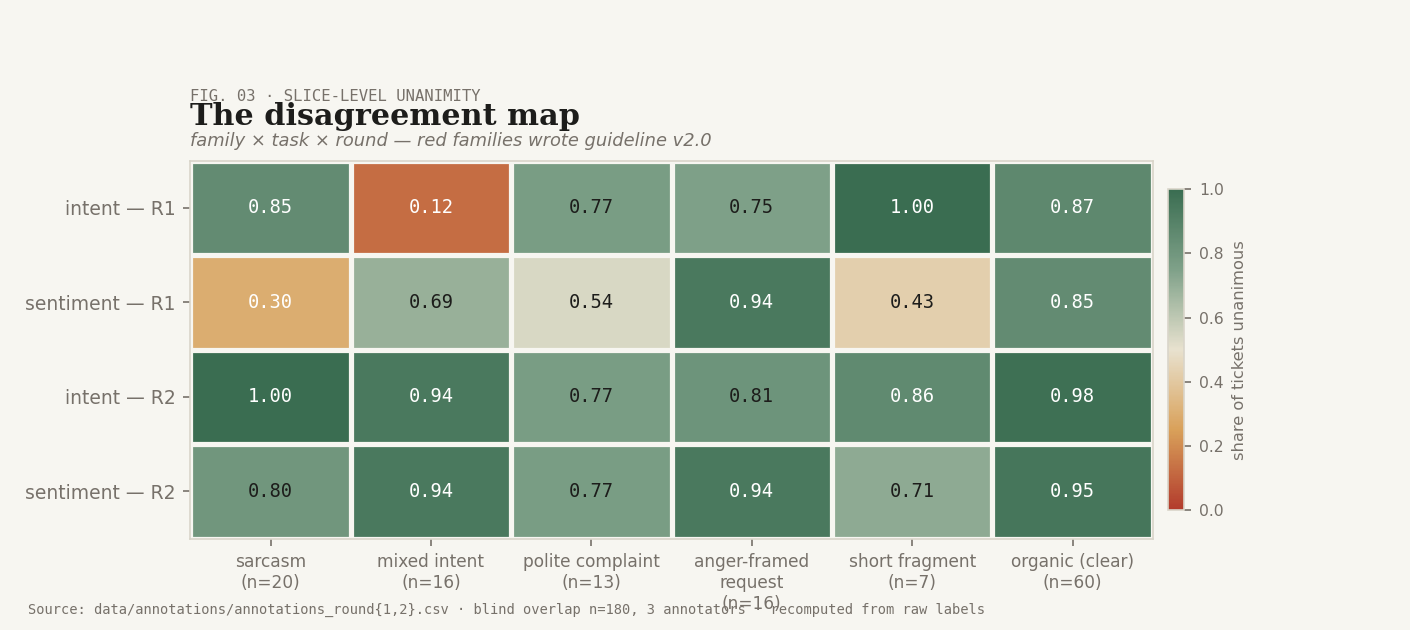

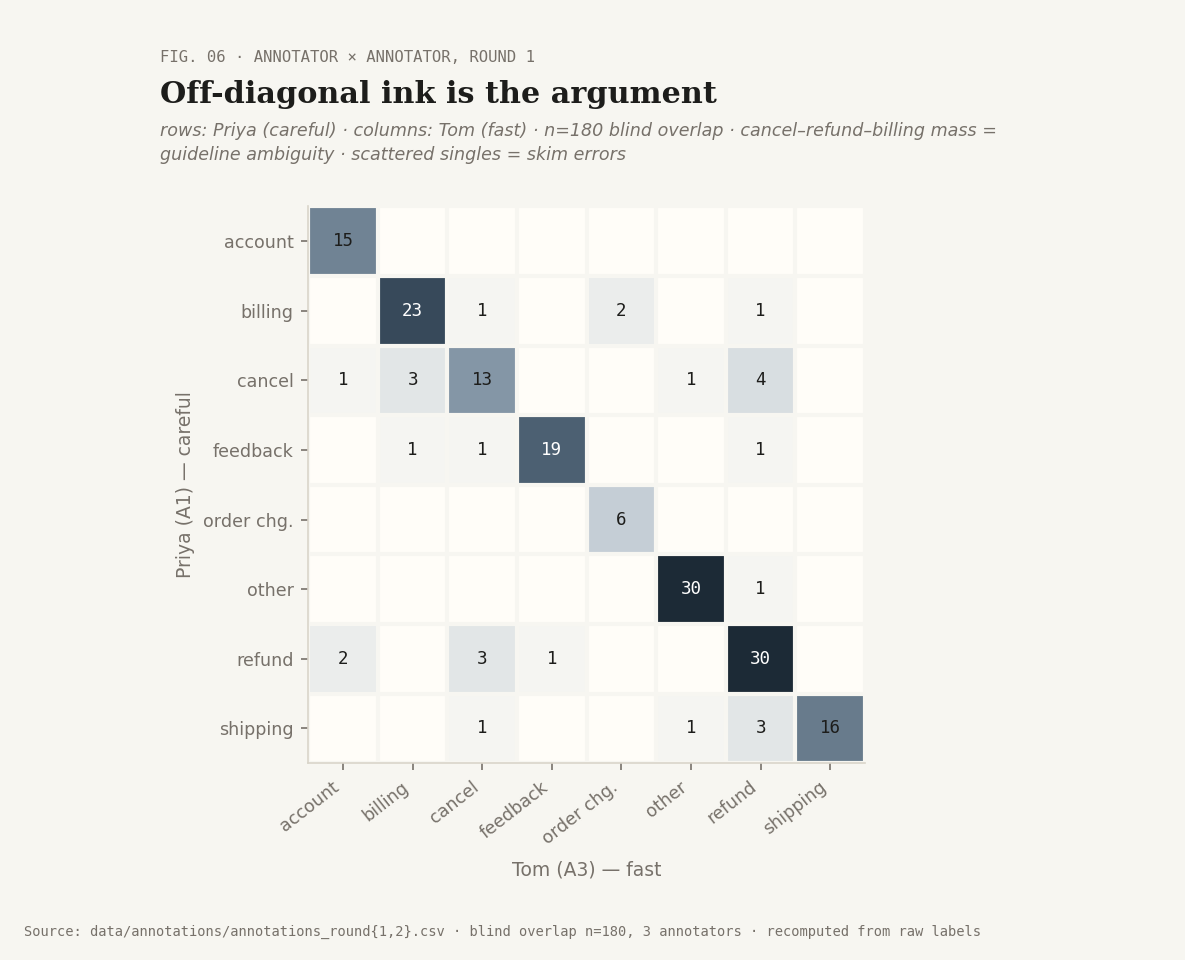

In [7]:
from IPython.display import Image, display
display(Image("../results/figures/fig_slices.png"))
display(Image("../results/figures/fig_confusion.png"))

The confusion matrix names the mechanism: the off-diagonal mass sits on
`cancellation ⇄ refund ⇄ billing` (mixed intents) — a **tie-breaking rule**
problem, not a taxonomy problem. Deleting `order_changes` or merging classes
would address nothing; a precedence hierarchy addresses everything. That
reasoning — slice → mechanism → targeted rule — is the core QA skill.

## 4 · Agreement is not correctness — the gold-set finding
The 16 anger-framed action requests were **75% unanimous** in Round 1 while
only **25% matched design intent** — all three annotators faithfully applied
v1's flawed tone-first rule (R4). The gold set is what separates "we agree"
from "we're right".

In [8]:
trap = M["R1"]["tone_trap_slice"]
print(f"anger-framed action requests (n={trap['n']}):")
print(f"  unanimous agreement among annotators: {trap['unanimous_agreement']:.0%}")
print(f"  accuracy vs design intent by annotator: {trap['accuracy_vs_design']}")
print("\n  example: 'This is ridiculous. Refund my card for order #3045073 NOW.'")
print("  v1 R4 → feedback_complaints (unanimous, wrong)  |  gold intent: refund_request")

ga = pd.DataFrame(M["R1"]["gold_accuracy"])
ga.columns = ["A1 (careful)", "A2 (empathetic)", "A3 (fast)"]
print("\nRound-1 gold accuracy by annotator:")
ga

anger-framed action requests (n=16):
  unanimous agreement among annotators: 75%
  accuracy vs design intent by annotator: {'A1': 0.25, 'A2': 0.25, 'A3': 0.25}

  example: 'This is ridiculous. Refund my card for order #3045073 NOW.'
  v1 R4 → feedback_complaints (unanimous, wrong)  |  gold intent: refund_request

Round-1 gold accuracy by annotator:


,A1 (careful),A2 (empathetic),A3 (fast)
intent_acc,0.8472,0.8889,0.8472
sentiment_acc,0.8056,0.9028,0.7361


**Counter-intuitive and important:** the *careful literalist* (A1) scored
**worse** on gold intent than the *empathetic skimmer* (A2) in Round 1 —
because A1 applied the flawed rule most faithfully. Diligence amplifies
guideline bugs; it cannot compensate for them. That is precisely why
guideline revision, not annotator retraining, was the correct intervention.

## 5 · Round 2 — did the revision work?

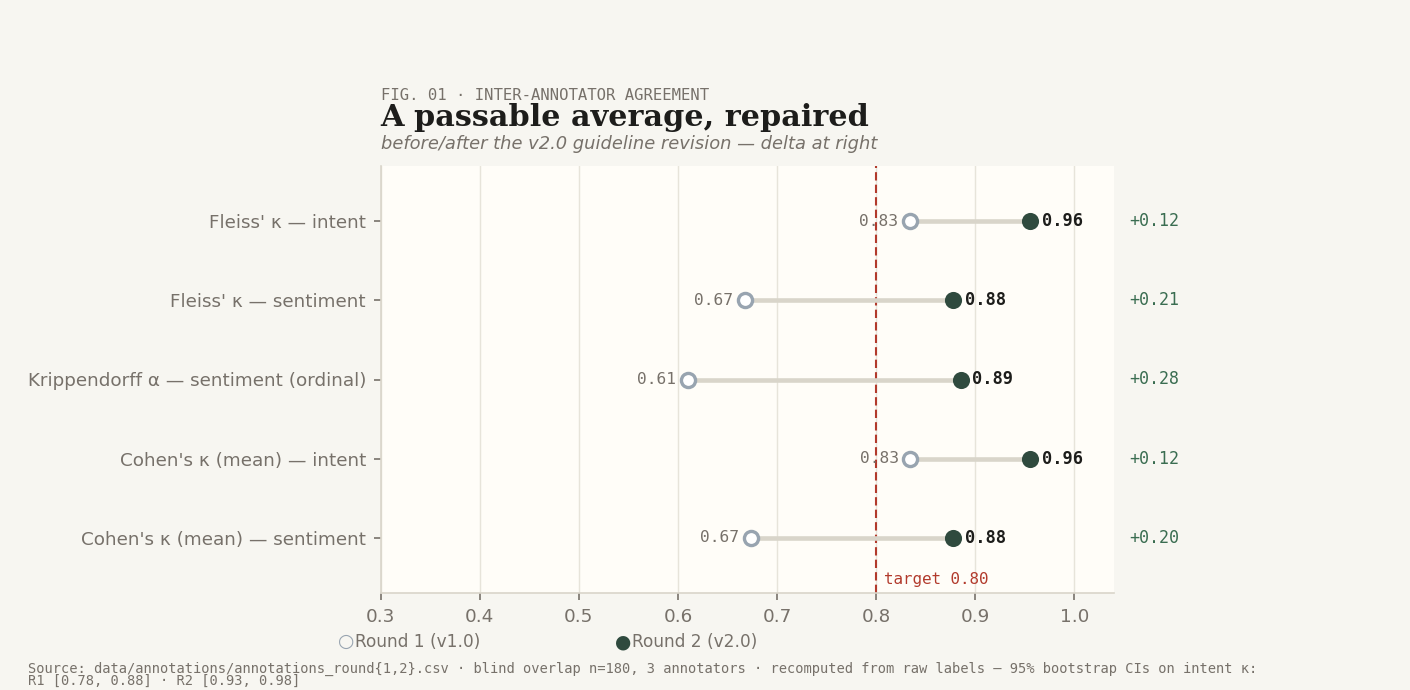

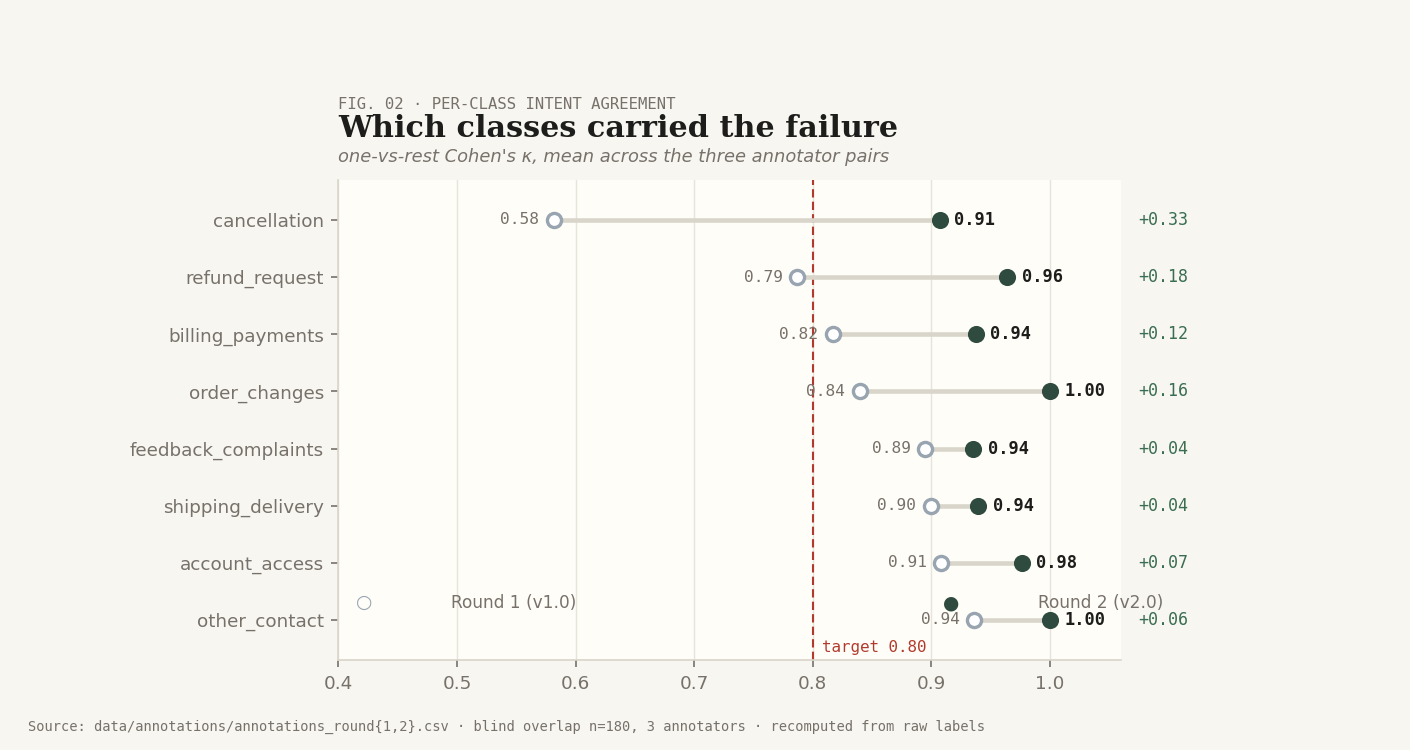

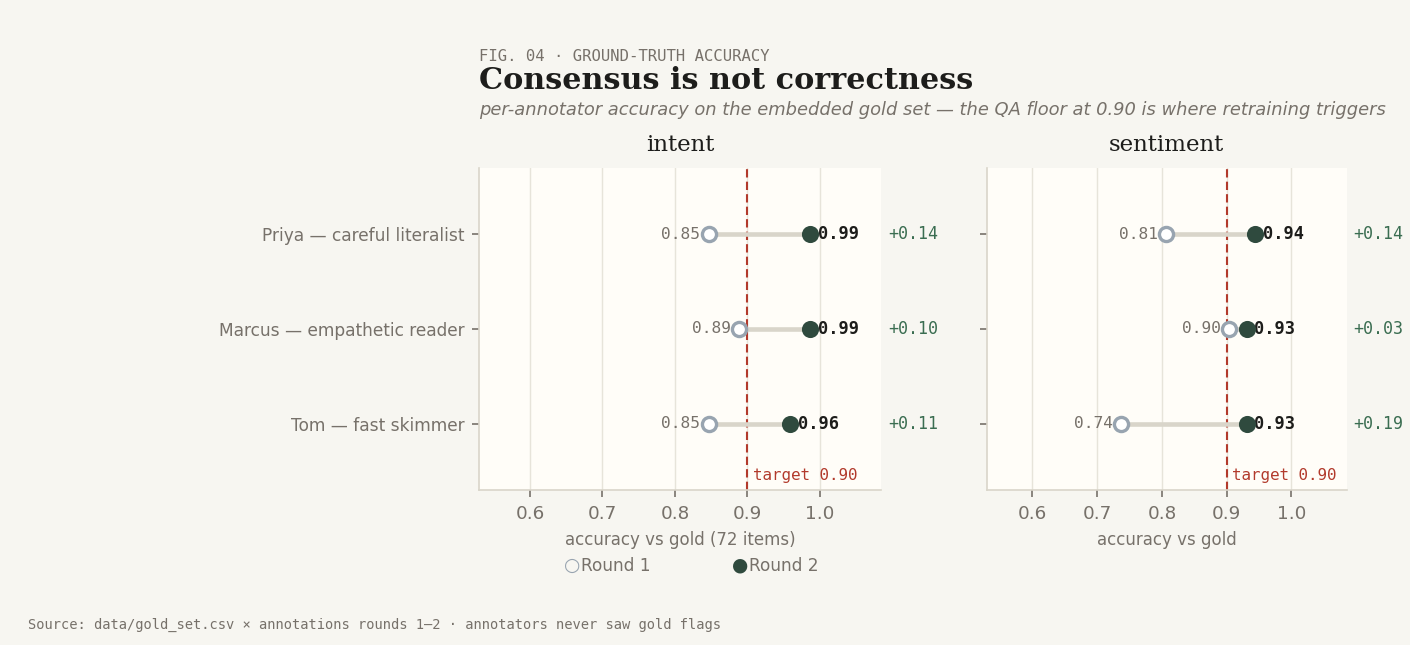

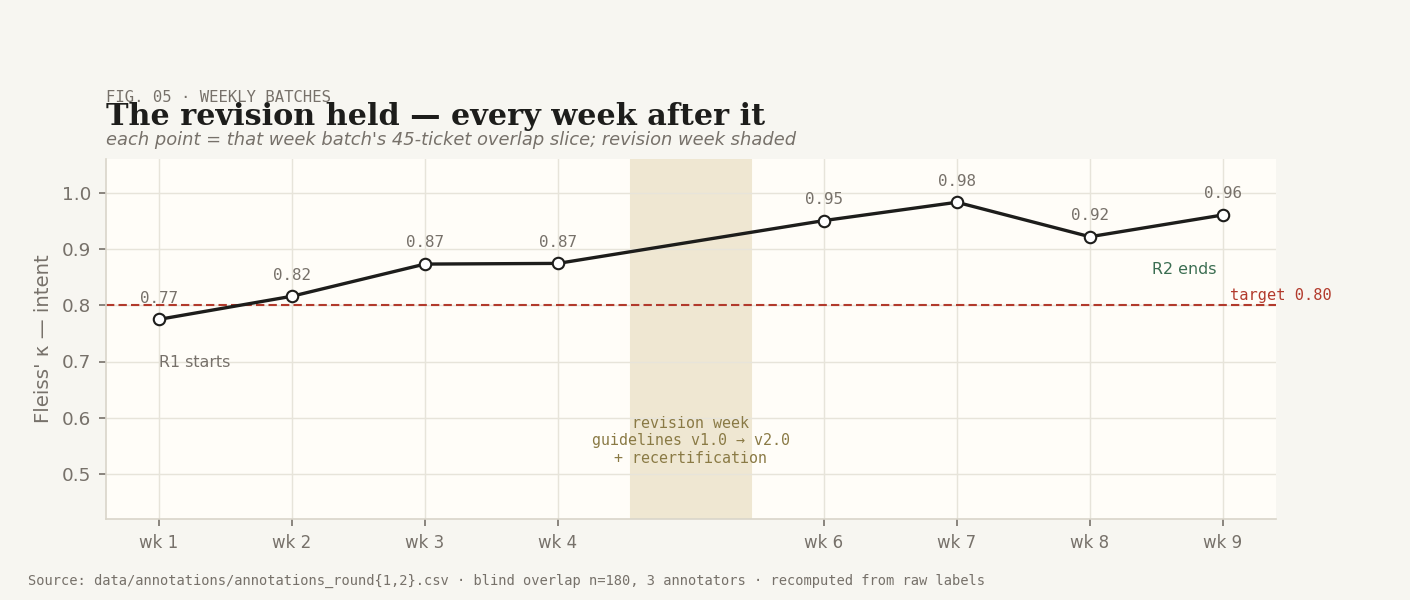

In [9]:
display(Image("../results/figures/fig_headline.png"))
display(Image("../results/figures/fig_perclass.png"))
display(Image("../results/figures/fig_gold.png"))
display(Image("../results/figures/fig_trend.png"))

## 6 · Tiered QA — rework and audit

Tier-2 review volume: {'prod_reviewed': 420, 'ov_reviewed': 29}
rework rate: intent 1.7% | sentiment 3.3% | either 4.7%
tier-3 audit: n=117  pass 100%
final labels vs gold: intent 1.000  sentiment 0.958

counterfactual cost of v1.0 (share of R1 production labels the v2 rules would have corrected):
  intents 4.8%, sentiments 14.5%


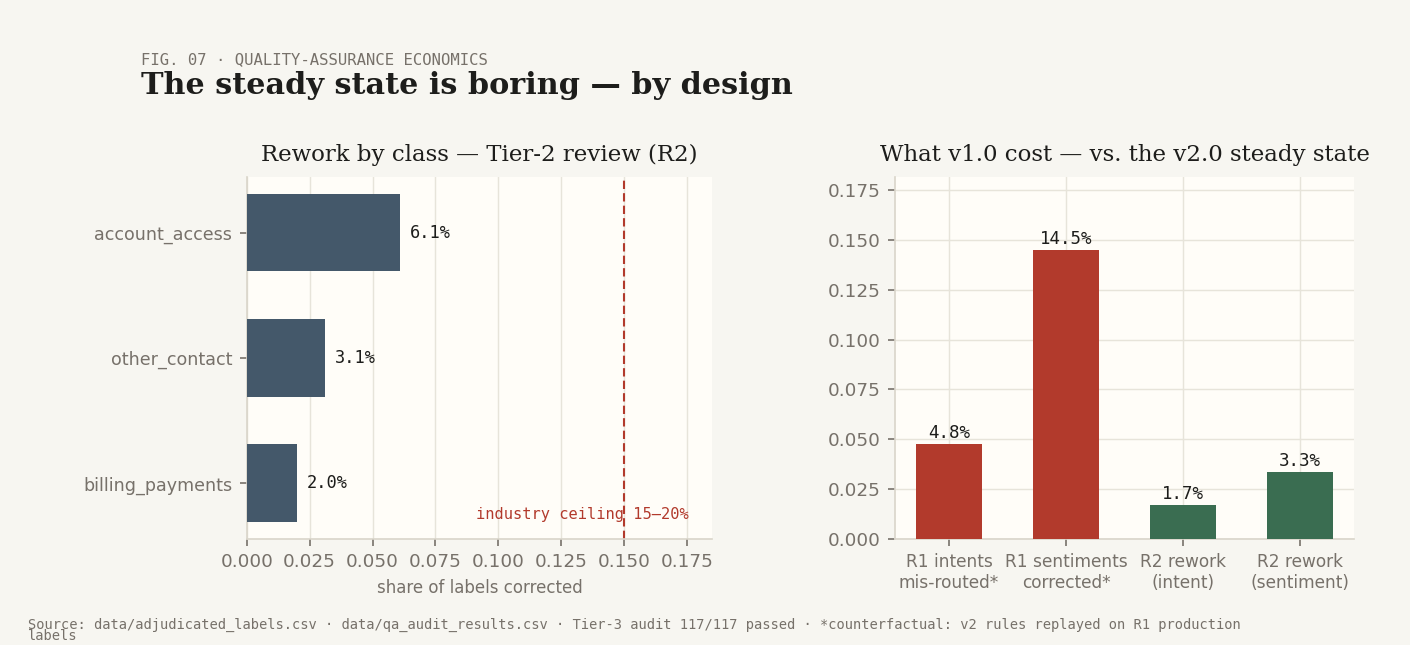

In [10]:
qa = M["qa"]
print(f"Tier-2 review volume: {qa['tier2_review_volume']}")
print(f"rework rate: intent {qa['rework_rate_intent']:.1%} | "
      f"sentiment {qa['rework_rate_sentiment']:.1%} | either {qa['rework_rate_either']:.1%}")
print(f"tier-3 audit: n={qa['tier3_audit']['n']}  pass {qa['tier3_audit']['pass_rate_overall']:.0%}")
print(f"final labels vs gold: intent {qa['final_gold_intent_acc']:.3f}  "
      f"sentiment {qa['final_gold_sentiment_acc']:.3f}")
cf = M["counterfactual_v1_cost"]
print(f"\ncounterfactual cost of v1.0 (share of R1 production labels the v2 "
      f"rules would have corrected):\n  intents {cf['r1_production_intents_misrouted_under_v2']:.1%}, "
      f"sentiments {cf['r1_production_sentiments_corrected_under_v2']:.1%}")
display(Image("../results/figures/fig_qa.png"))

## 7 · Conclusions

1. **Overall agreement conceals; slices reveal.** Round-1 intent κ = 0.83
   looked shippable while mixed intents ran at chance level (κ = 0.03).
2. **Agreement ≠ correctness.** The anger-framed family agreed-and-wrong at
   75% unanimity; only the gold set caught it.
3. **Guidelines, not annotators, were the defect** — and the cheap fix was
   a rule change (precedence hierarchy, sarcasm rule, politeness rule).
   Intent κ 0.83 → **0.96**, ordinal α (sentiment) 0.61 → **0.89**.
4. **QA economics:** steady-state rework ~2–5% (< 15–20% ceiling), audit
   pass 100%, final gold accuracy 1.00 intent / 0.96 sentiment.
5. **Known gap (v2.1 backlog):** statement-form policy questions
   ("i cannot check ur money back guarantee" — no `?`, policy gate misses)
   and keyword-invisible typos ("acvount") — logged with examples in the
   QA writeup.